In [ ]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 10.3 MB/s eta 0:00:00


In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import tensorflow as tf
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

In [ ]:
np.random.seed(180)
tf.random.set_seed(180)

In [ ]:
people = fetch_lfw_people(min_faces_per_person=20,resize=0.7)
print(people.data.shape)
print(people.target.shape)
image_shape = people.images[0].shape

(3023, 5655)
(3023,)


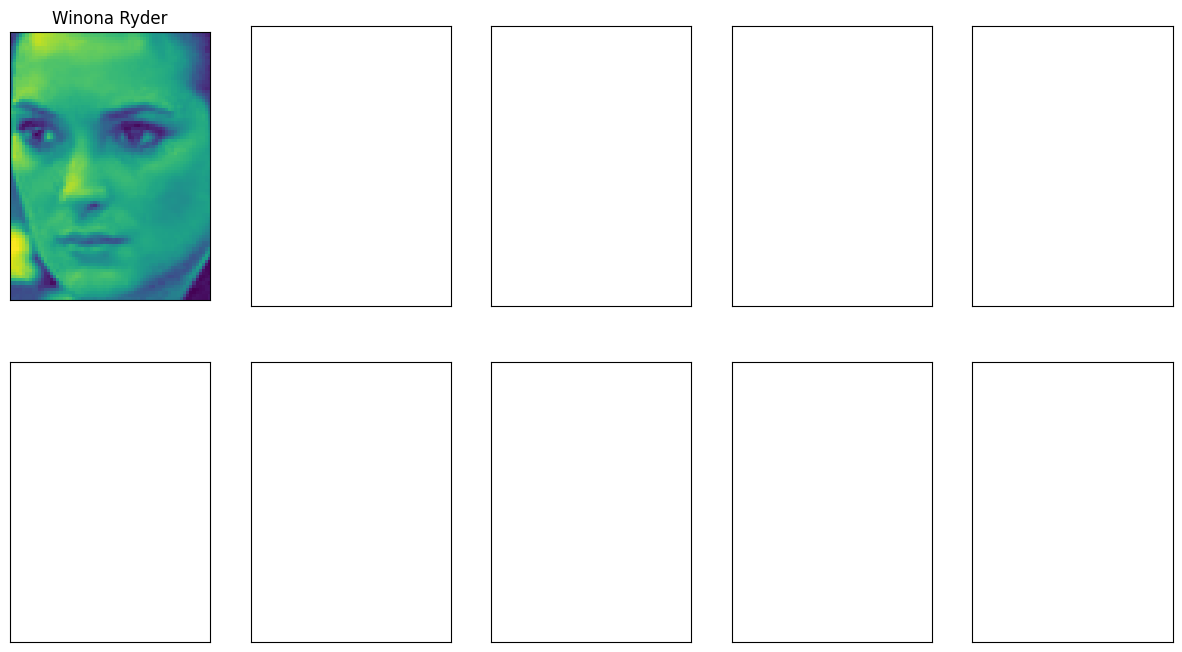

In [ ]:
fix, axes = plt.subplots(2,5,figsize=(15,8),subplot_kw={'xticks':(), 'yticks':()})
for target, image, ax in zip(people.target,people.images,axes.ravel()):
 ax.imshow(image)
 ax.set_title(people.target_names[target])
 plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(people.data,people.target, test_size=0.2,
random_state=20)
y_train = y_train.astype(int)
y_test = y_test.astype(int)
batch_size = len(X_train)
print(X_train.shape,y_train.shape,y_test.shape)
print("people.images.shape: {}".format(people.images.shape))
print("Number of classes: {}".format(len(people.target_names)))


(2418, 5655) (2418,) (605,)
people.images.shape: (3023, 87, 65)
Number of classes: 62


In [ ]:
count = np.bincount(people.target)
for i, (count, name) in enumerate(zip(count, people.target_names)):
  print( "{0:25} {1:3}".format(name,count),end=" ")
  if (i+1)%3 == 0:
    print()


Alejandro Toledo           39 Alvaro Uribe               35 Amelie Mauresmo            21 
Andre Agassi               36 Angelina Jolie             20 Ariel Sharon               77 
Arnold Schwarzenegger      42 Atal Bihari Vajpayee       24 Bill Clinton               29 
Carlos Menem               21 Colin Powell              236 David Beckham              31 
Donald Rumsfeld           121 George Robertson           22 George W Bush             530 
Gerhard Schroeder         109 Gloria Macapagal Arroyo    44 Gray Davis                 26 
Guillermo Coria            30 Hamid Karzai               22 Hans Blix                  39 
Hugo Chavez                71 Igor Ivanov                20 Jack Straw                 28 
Jacques Chirac             52 Jean Chretien              55 Jennifer Aniston           21 
Jennifer Capriati          42 Jennifer Lopez             21 Jeremy Greenstock          24 
Jiang Zemin                20 John Ashcroft              53 John Negroponte            31 

In [ ]:
mask = np.zeros(people.target.shape,dtype=np.bool_)
for target in np.unique(people.target):
 mask[np.where(people.target == target)[0][:50]] = True
X_people = people.data[mask]
y_people = people.target[mask]
X_people = X_people / 255.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_people, y_people, stratify=y_people, random_state=0
)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

print("Test set score of 1-nn: {:.2f}".format(knn.score(X_test, y_test)))

Test set score of 1-nn: 0.22


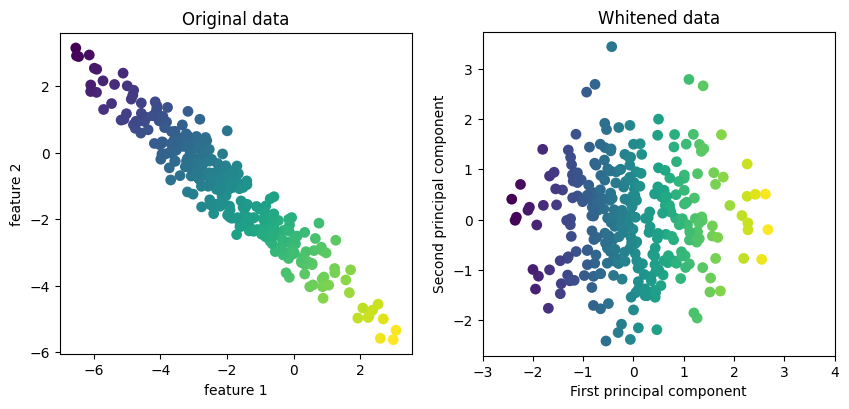

In [ ]:
mglearn.plots.plot_pca_whitening()
plt.show()


In [ ]:
pca = PCA(n_components=100,whiten=True,random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print("X_train_pca.shape: {}".format(X_train_pca.shape))
# KNN with PCA
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca,y_train)
print("Test set accuracy: {:.2f}".format(knn.score(X_test_pca,y_test)))
print("pca.components_.shape: {}".format(pca.components_.shape))

X_train_pca.shape: (1547, 100)
Test set accuracy: 0.30
pca.components_.shape: (100, 5655)


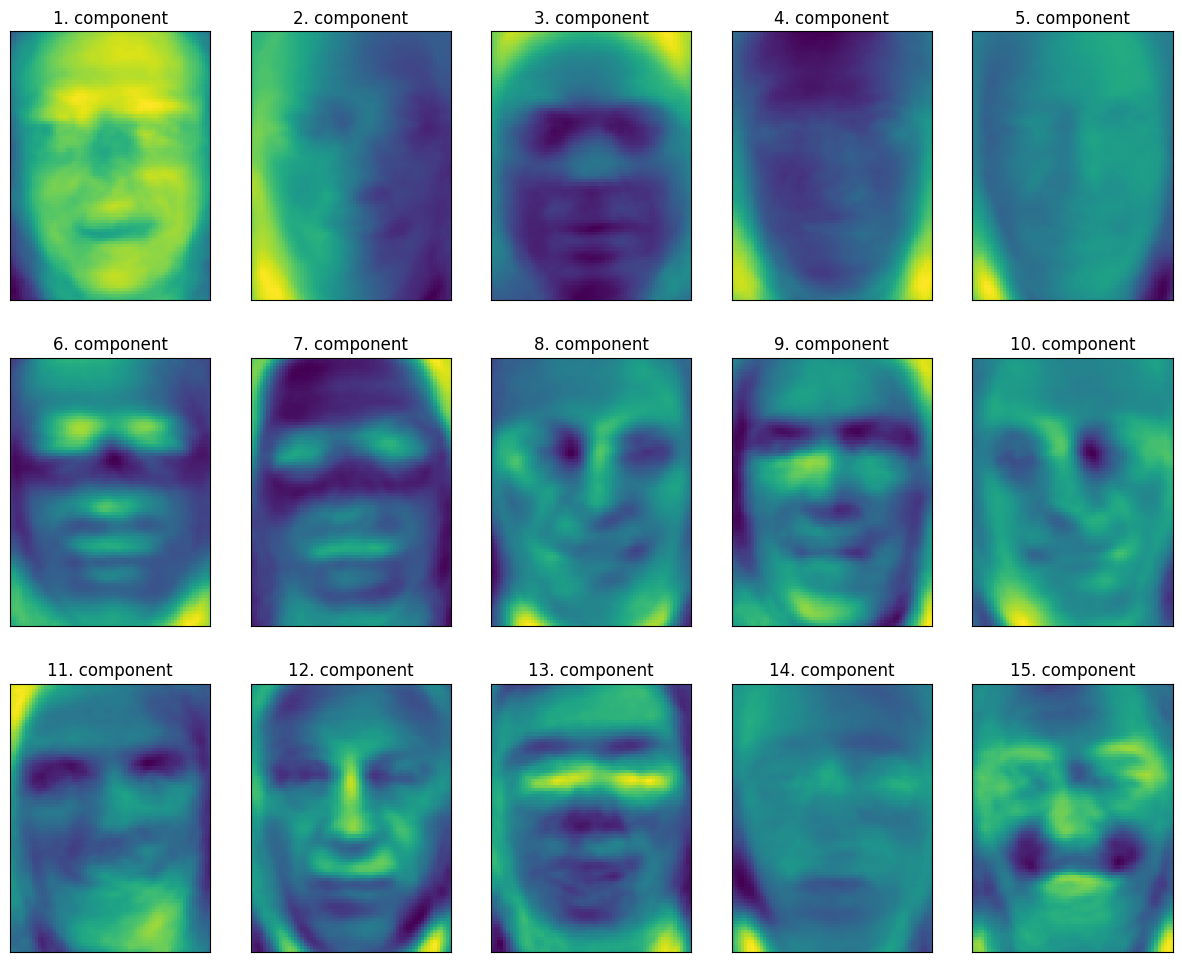

In [ ]:
fix, axes = plt.subplots(3,5,figsize=(15,12), subplot_kw={'xticks':(), 'yticks':()})
for i, (component, ax) in enumerate(zip(pca.components_, axes.ravel())):
 ax.imshow(component.reshape(image_shape),cmap='viridis')
 ax.set_title("{}. component".format(i+1))
plt.show()


In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform( X_train_pca)
X_test_scaled = scaler.transform(X_test_pca)

In [ ]:
model = Sequential([
    Input(shape=(100,)),
    Dense(300, activation='relu'),
    Dense(100, activation='relu'),
    Dense(len(np.unique(y_train)), activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit( X_train_scaled,y_train,batch_size=50,epochs=20,shuffle=False,
verbose=1)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0168 - loss: 4.1312
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0284 - loss: 4.0889
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0368 - loss: 4.0664
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0524 - loss: 4.0471
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.0646 - loss: 4.0258
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0743 - loss: 4.0060
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1015 - loss: 3.9752
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1164 - loss: 3.9358
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1390 - loss: 3.8873
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1577 - loss: 3.8262
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1745 - loss: 3.7530
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2049 - l

In [ ]:
loss, accuracy = model.evaluate( X_test_scaled,y_test,verbose=1)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3178 - loss: 2.8964
Test Loss: 2.8963782787323
Test Accuracy: 0.3178294599056244


In [ ]:
%pip install SageMaker

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 376.6 kB/s eta 0:00:00
INFO: pip is looking at multiple versions of aiobotocore to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of aiobotocore to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which

In [ ]:
pip install -q sagemaker boto3

In [ ]:
import sagemaker
import boto3
import pandas as pd
import numpy as np
print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
X = df.iloc[:, :-1]
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,
random_state=42 )
model = RandomForestClassifier()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 1.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
from sklearn import datasets

In [ ]:
iris=datasets.load_iris()
iris_data=iris.data
iris_labels=iris.target
print(iris_data)


[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [ ]:
x_train, x_test, y_train, y_test=(train_test_split(iris_data, iris_labels, test_size=0.20))


In [ ]:
classifier=KNeighborsClassifier(n_neighbors=6)
classifier.fit(x_train, y_train)
y_pred=classifier.predict(x_test)


In [ ]:
print("accuracy is")
print(classification_report(y_test, y_pred))

accuracy is
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.67      1.00      0.80         6
           2       1.00      0.77      0.87        13

    accuracy                           0.90        30
   macro avg       0.89      0.92      0.89        30
weighted avg       0.93      0.90      0.90        30



In [ ]:
cm=confusion_matrix(y_test, y_pred)
cm


array([[11,  0,  0],
       [ 0,  6,  0],
       [ 0,  3, 10]])

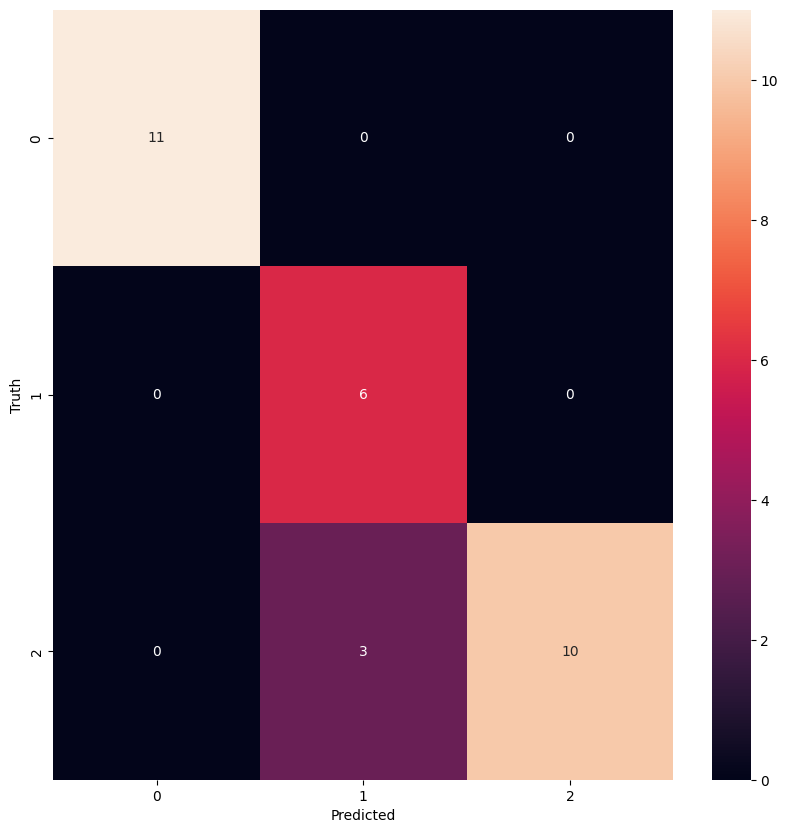

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize=(10,10))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt. savefig("exercise5.png")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
data = pd.read_csv(url)

bill = np.array(data.total_bill)
tip = np.array(data.tip)

In [ ]:


def localweight(point, xmat, ymat, k):
    m, n = np.shape(xmat)
    weights = np.eye(m)
    for j in range(m):
        diff = point - xmat[j]
        weights[j, j] = np.exp(diff * diff.T / (-2.0 * k**2))
    W = (xmat.T * (weights * xmat)).I * (xmat.T * (weights * ymat.T))
    return W

def localweightRegression(xmat, ymat, k):
    m, n = np.shape(xmat)
    ypred = np.zeros(m)
    for i in range(m):
        ypred[i] = (xmat[i] * localweight(xmat[i], xmat, ymat, k)).item()
    return ypred

mbill = np.matrix(bill)
mtip = np.matrix(tip)
m = np.shape(mbill)[1]
one = np.matrix(np.ones(m))
X = np.hstack((one.T, mbill.T))

ypred = localweightRegression(X, mtip, 0.5)
SortIndex = X[:, 1].argsort(0)
xsort = X[SortIndex][:, 0]

/tmp/ipykernel_9975/3333919440.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  weights[j, j] = np.exp(diff * diff.T / (-2.0 * k**2))


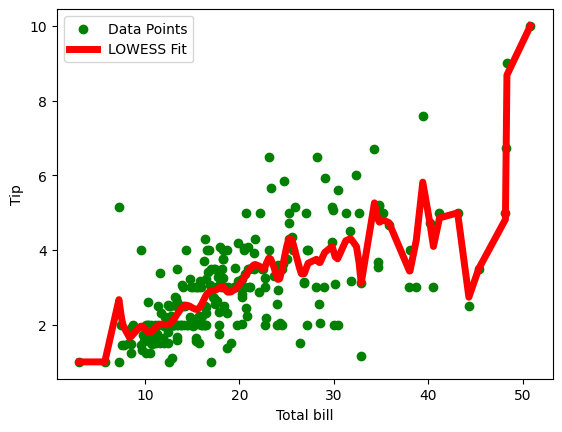

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.scatter(bill, tip, color='green', label='Data Points')
x_axis_line = np.squeeze(np.asarray(xsort[:, 1]))
y_axis_line = np.squeeze(np.asarray(ypred[SortIndex]))
ax.plot(x_axis_line, y_axis_line, color='red', linewidth=5, label='LOWESS Fit')
plt.xlabel('Total bill')
plt.ylabel('Tip')
plt.legend()
plt.savefig("exercise6.png")
plt.show()

In [ ]:
%pip install nltk

In [ ]:
import numpy as np
import pandas as pd
import nltk
import re
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import pandas as pd

df = pd.read_csv('Restaurant_Reviews.tsv', delimiter='\t', quoting=3)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Restaurant_Reviews.tsv'

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/Aakash-S/Restaurant-Review-Analysis/master/Restaurant_Reviews.tsv"
df = pd.read_csv(url, delimiter='\t', quoting=3)
df.head()

HTTPError: HTTP Error 404: Not Found

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/skathirmani/datasets/main/Restaurant_Reviews.tsv"
df = pd.read_csv(url, delimiter='\t', quoting=3)
df.head()

HTTPError: HTTP Error 404: Not Found

In [ ]:
df.shape


(150, 5)

In [ ]:
corpus = []
for i in range(0,1000):
 # Cleaning special character from the reviews
 review = re.sub(pattern='[^a-zA-Z]',repl=' ', string=df['Review'][i])
 # Converting the entire review into lower case
 review = review.lower()
 # Tokenizing the review by words
 review_words = review.split()
 # Removing the stop words
 review_words = [word for word in review_words if not word in
set(stopwords.words('english'))]
 # Stemming the words
 ps = PorterStemmer()
 review = [ps.stem(word) for word in review_words]
 # Joining the stemmed words
 review = ' '.join(review)
 # Creating a corpus
 corpus.append(review)
print(corpus[0:10])


KeyError: 'Review'

In [ ]:
# Strip leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Print column names to confirm
print(df.columns)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')


In [ ]:
# Strip leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Print column names to confirm
print(df.columns)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')


ValueError: empty vocabulary; perhaps the documents only contain stop words